# 조선 섹터 퀀트 케이스스터디
## Part A. 조선주는 언제 '테마'로 움직이나 — 섹터 동조화 측정
## Part B. 수주 공시는 뉴스인가 — 수주 공시 이벤트 스터디

**사용법 (Google Colab 기준)**
1. [OpenDART](https://opendart.fss.or.kr) 가입 → 인증키 신청 (무료, 즉시 발급)
2. 아래 설정 셀의 `DART_API_KEY`에 키 입력
3. `런타임 → 모두 실행`

| 가설 | 내용 | 검정 |
|---|---|---|
| A1 | 조선주 간 초과수익 상관(테마 강도)은 시기별로 크게 변하고, 특정 이벤트에 급등한다 | 60일 롤링 평균 상관 |
| A2 | 테마 강도가 높은 구간 이후 섹터 초과수익은 반전된다 | 레짐별 선행 수익률, Newey-West t |
| H1 | 수주 공시일 [0,+1]의 초과수익은 작다 (이미 반영) | 시장모형 CAR |
| H2 | 공시 전 [-10,-1]에 유의한 초과수익이 있다 (선반영·정보유출) | 시장모형 CAR |
| H3 | 테마 강도가 높을 때 개별 공시 반응은 약하고, 경쟁사로의 스필오버는 크다 | 레짐별 CAR, 경쟁사 CAR |

In [1]:
# %pip = 현재 커널의 python에 설치 (!pip는 PATH상의 다른 python에 설치될 수 있음)
%pip install -q finance-datareader pykrx opendartreader statsmodels

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, time, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
plt.rcParams["figure.dpi"] = 110

DART_API_KEY = os.environ["DART_API_KEY"]    # 환경변수에서 읽음 (키 문자열을 노트북·출력에 남기지 않음)
assert DART_API_KEY.strip(), "환경변수 DART_API_KEY가 비어 있습니다"
START = "2015-01-01"
END   = pd.Timestamp.today().strftime("%Y-%m-%d")
OUT_DIR = "outputs"                          # 그래프·표 저장 폴더
os.makedirs(OUT_DIR, exist_ok=True)

# 조선 유니버스  종목코드: (그래프용 영문 라벨, 그룹)
# 합병·상장폐지된 종목은 데이터가 있는 기간까지만 자동 사용됨
UNIVERSE = {
    "009540": ("HD KSOE(Hold)",  "HD"),
    "329180": ("HD HHI",         "HD"),
    "010620": ("HD Mipo",        "HD"),
    "010140": ("Samsung HI",     "SHI"),
    "042660": ("Hanwha Ocean",   "HANWHA"),
    "097230": ("HJ Shipbuilding","HJ"),
}
NAME  = {k: v[0] for k, v in UNIVERSE.items()}
GROUP = {k: v[1] for k, v in UNIVERSE.items()}

# 지주사는 자회사와 기계적으로 상관이 높아 동조화 계산에서 제외
CORR_EXCLUDE = ["009540"]
# HJ중공업은 건설부문 공급계약도 같은 이름으로 공시되므로 이벤트 스터디 기본값에서 제외
EVENT_TICKERS = ["009540", "329180", "010620", "010140", "042660"]

ROLL_WIN    = 60          # 동조화 롤링 윈도우(거래일)
EST_WIN     = (-250, -30) # 시장모형 추정구간
EVT_WIN     = (-10, 10)   # 이벤트 윈도우
MIN_EST_OBS = 120
REL = np.arange(EVT_WIN[0], EVT_WIN[1] + 1)

---
## Step 0. 주가 데이터
pykrx(수정주가)를 우선 쓰고, 실패하면 FinanceDataReader로 대체합니다.
거래정지일(거래량 0)과 일간 ±30% 초과 수익률(가격제한폭 밖 = 감자·데이터 오류)은 제거합니다.

In [3]:
def _load_one(ticker, start, end):
    s, e = start.replace("-", ""), end.replace("-", "")
    try:
        from pykrx import stock
        df = stock.get_market_ohlcv(s, e, ticker)          # adjusted=True 기본
        if df is not None and not df.empty:
            return df.rename(columns={"종가": "Close", "거래량": "Volume"})[["Close", "Volume"]]
    except Exception as ex:
        print(f"  pykrx 실패({ticker}): {ex}")
    try:
        import FinanceDataReader as fdr
        df = fdr.DataReader(ticker, start, end)
        if df is not None and not df.empty:
            print(f"  FDR 사용({ticker})")
            return df[["Close", "Volume"]]
    except Exception as ex:
        print(f"  FDR 실패({ticker}): {ex}")
    return None

def _load_kospi(start, end):
    try:
        from pykrx import stock
        df = stock.get_index_ohlcv(start.replace("-", ""), end.replace("-", ""), "1001")
        if df is not None and not df.empty:
            return df["종가"].rename("KOSPI")
    except Exception as ex:
        print(f"  pykrx 지수 실패: {ex}")
    import FinanceDataReader as fdr
    return fdr.DataReader("KS11", start, end)["Close"].rename("KOSPI")

def load_all(universe, start, end):
    close, vol = {}, {}
    for t in universe:
        print(f"loading {t} {NAME[t]}")
        df = _load_one(t, start, end)
        if df is None:
            print(f"  -> {t} 제외")
            continue
        close[t], vol[t] = df["Close"], df["Volume"]
        time.sleep(0.3)
    kospi = _load_kospi(start, end)
    kospi.index = pd.to_datetime(kospi.index)
    close = pd.DataFrame(close); close.index = pd.to_datetime(close.index)
    vol   = pd.DataFrame(vol);   vol.index   = pd.to_datetime(vol.index)
    return close.reindex(kospi.index), vol.reindex(kospi.index), kospi

def to_returns(close, vol, kospi, cap=0.30, tol=0.005):
    ret = close.pct_change(fill_method=None)
    ret = ret.mask((vol == 0) | vol.isna())
    # 정확히 ±30%인 상·하한가는 정상 관측치 → 부동소수점(1.3-1=0.30000000000000004)·수정주가 반올림 오차만큼 허용
    bad = ret.abs() > cap + tol
    if int(bad.values.sum()):
        print(f"|일간수익률| > {cap + tol:.1%} 관측치 {int(bad.values.sum())}개 NaN 처리")
    ret = ret.mask(bad)
    mkt = kospi.pct_change(fill_method=None)
    return ret, mkt

In [4]:
close, vol, kospi = load_all(UNIVERSE, START, END)
ret, mkt = to_returns(close, vol, kospi)
print("\n종목별 유효 수익률 관측치:")
print(ret.notna().sum().rename(NAME))
print(f"\nKOSPI {kospi.index.min().date()} ~ {kospi.index.max().date()} ({kospi.notna().sum()}일)")
coverage = pd.DataFrame({"name": pd.Series(NAME),
                         "first": close.apply(lambda s: s.first_valid_index()),
                         "last": close.apply(lambda s: s.last_valid_index()),
                         "vol0_days": (vol == 0).sum(), "valid_ret": ret.notna().sum()})
coverage.to_csv(f"{OUT_DIR}/data_coverage.csv", encoding="utf-8-sig")

loading 009540 HD KSOE(Hold)
KRX 로그인 실패: KRX_ID 또는 KRX_PW 환경 변수가 설정되지 않았습니다.


loading 329180 HD HHI


loading 010620 HD Mipo


loading 010140 Samsung HI


loading 042660 Hanwha Ocean


loading 097230 HJ Shipbuilding


Error occurred in get_index_ohlcv_by_date: Expecting value: line 1 column 1 (char 0)
Error occurred in __fetch: Expecting value: line 1 column 1 (char 0)
  pykrx 지수 실패: '지수명'



종목별 유효 수익률 관측치:
HD KSOE(Hold)      2849
HD HHI             1221
HD Mipo            2676
Samsung HI         2862
Hanwha Ocean       2559
HJ Shipbuilding    2814
dtype: int64

KOSPI 2015-01-02 ~ 2026-09-17 (2875일)


---
# Part A. 섹터 동조화 (테마 강도)
**테마 강도** = 조선주들의 *시장조정수익률*(종목수익률 − KOSPI) 사이 60일 평균 쌍별 상관계수  
시장 전체가 같이 움직여서 생기는 상관은 빼고, "조선이라서" 같이 움직이는 부분만 남기는 것이 핵심.

레짐 구분은 **룩어헤드 방지**를 위해 그날까지의 과거 분포 대비 백분위(expanding rank)로 합니다.
상위 20% = High, 하위 20% = Low.

In [5]:
def rolling_avg_corr(x, window=60, min_assets=3, min_frac=0.8):
    vals = np.full(len(x), np.nan)
    for i in range(window - 1, len(x)):
        sub = x.iloc[i - window + 1:i + 1]
        sub = sub.loc[:, sub.notna().sum() >= int(window * min_frac)]
        if sub.shape[1] < min_assets:
            continue
        c = sub.corr().values
        iu = np.triu_indices(c.shape[0], 1)
        vals[i] = np.nanmean(c[iu])
    return pd.Series(vals, index=x.index)

corr_cols = [c for c in ret.columns if c not in CORR_EXCLUDE]
ex_ret  = ret[corr_cols].sub(mkt, axis=0)                  # 시장조정수익률
theme     = rolling_avg_corr(ex_ret,       ROLL_WIN).rename("theme (market-adj)")
theme_raw = rolling_avg_corr(ret[corr_cols], ROLL_WIN).rename("raw corr")

theme_rank = theme.expanding(min_periods=250).rank(pct=True)
def to_regime(r):
    return pd.cut(r, [0, 0.2, 0.8, 1.0], labels=["Low", "Mid", "High"], include_lowest=True)
regime = to_regime(theme_rank)

sector_ex = ex_ret.mean(axis=1, skipna=True)               # 동일가중 섹터 초과수익
print(theme.describe())
print("\n레짐 분포:\n", regime.value_counts())
pd.DataFrame({"theme": theme, "theme_raw": theme_raw, "theme_rank": theme_rank, "regime": regime,
              "sector_ex": sector_ex}).to_csv(f"{OUT_DIR}/A1_theme_series.csv", encoding="utf-8-sig")

count   2,816.0000
mean        0.4301
std         0.1126
min         0.0958
25%         0.3414
50%         0.4330
75%         0.5173
max         0.7562
Name: theme (market-adj), dtype: float64

레짐 분포:
 theme (market-adj)
Mid     1572
High     644
Low      351
Name: count, dtype: int64


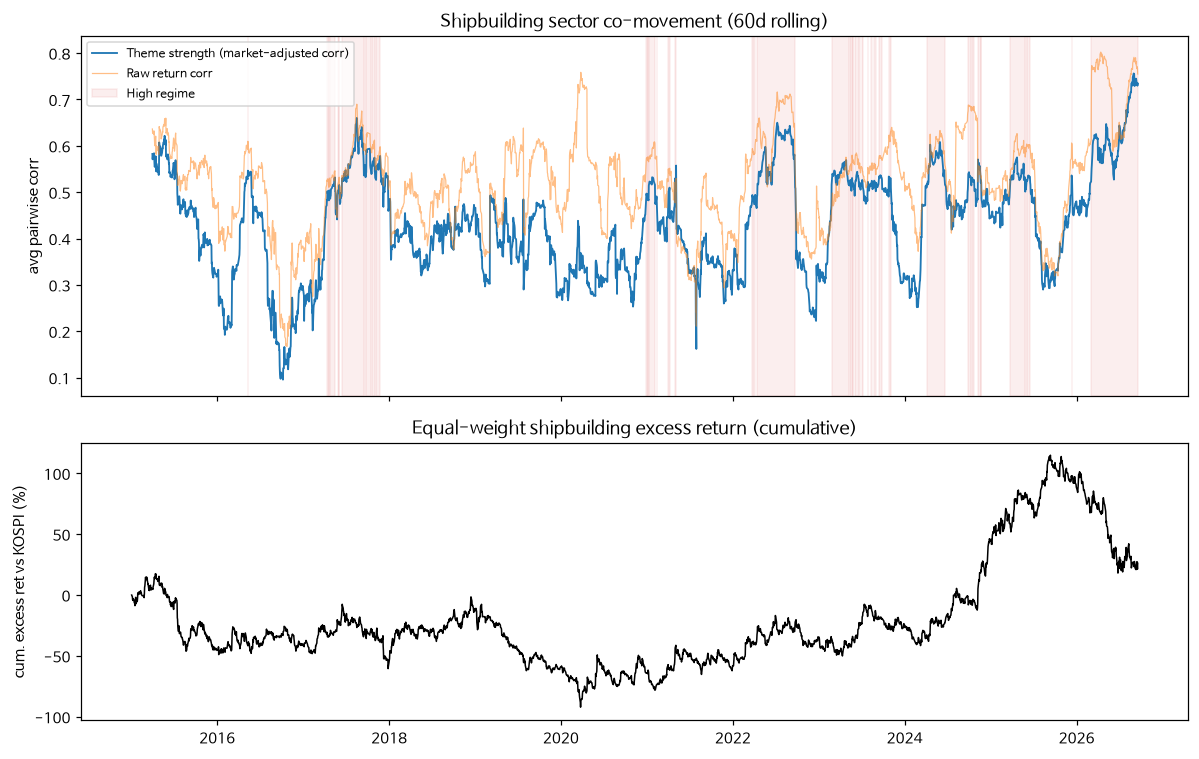

테마 강도 상위 시점 → 이 날짜 전후 뉴스를 찾아 슬라이드에 매칭하세요


,date,theme_corr
0,2026-08-31,0.7562
1,2017-08-16,0.6602
2,2022-07-08,0.6498
3,2026-05-06,0.6471
4,2015-05-22,0.6216
5,2024-05-29,0.6083


In [6]:
def top_peaks(s, k=6, gap=60):
    s = s.dropna().copy(); picks = []
    while len(picks) < k and len(s):
        d = s.idxmax(); picks.append((d.date(), s[d]))
        p = s.index.get_loc(d)
        s = s.drop(s.index[max(0, p - gap):p + gap + 1])
    return pd.DataFrame(picks, columns=["date", "theme_corr"])

fig, ax = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                       gridspec_kw={"height_ratios": [1.3, 1]})
ax[0].plot(theme.index, theme, lw=1.2, label="Theme strength (market-adjusted corr)")
ax[0].plot(theme_raw.index, theme_raw, lw=0.8, alpha=0.5, label="Raw return corr")
hi = (regime == "High")
ax[0].fill_between(theme.index, 0, 1, where=hi.values, transform=ax[0].get_xaxis_transform(),
                   color="tab:red", alpha=0.08, label="High regime")
ax[0].set_ylabel("avg pairwise corr"); ax[0].legend(loc="upper left", fontsize=8)
ax[0].set_title(f"Shipbuilding sector co-movement ({ROLL_WIN}d rolling)")
ax[1].plot(sector_ex.index, sector_ex.fillna(0).cumsum() * 100, color="k", lw=1)
ax[1].set_ylabel("cum. excess ret vs KOSPI (%)")
ax[1].set_title("Equal-weight shipbuilding excess return (cumulative)")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig_A1_theme.png", bbox_inches="tight"); plt.show()

peaks = top_peaks(theme)
print("테마 강도 상위 시점 → 이 날짜 전후 뉴스를 찾아 슬라이드에 매칭하세요")
display(peaks)
peaks.to_csv(f"{OUT_DIR}/A1_theme_peaks.csv", index=False, encoding="utf-8-sig")

### A2. 테마 강도가 높은 뒤에는 반전되는가
t일 레짐 기준으로 t+1 ~ t+h 섹터 초과수익 합을 보고, 겹치는 보유기간 때문에 Newey-West(lag = h) 표준오차를 씁니다.

In [7]:
def fwd_sum(s, h):
    return s.rolling(h, min_periods=int(h * 0.8)).sum().shift(-h)

def nw_mean(y, lags):
    y = y.dropna()
    if len(y) < 30:
        return np.nan, np.nan, len(y)
    res = sm.OLS(y.values, np.ones(len(y))).fit(cov_type="HAC", cov_kwds={"maxlags": lags})
    return res.params[0], res.tvalues[0], len(y)

def nw_diff(y, is_high, lags):
    d = pd.concat([y, is_high.astype(float)], axis=1).dropna()
    X = sm.add_constant(d.iloc[:, 1].values)
    res = sm.OLS(d.iloc[:, 0].values, X).fit(cov_type="HAC", cov_kwds={"maxlags": lags})
    return res.params[1], res.tvalues[1]

rows = []
for h in [5, 20, 60]:
    f = fwd_sum(sector_ex, h)
    for g in ["Low", "Mid", "High"]:
        m, t, n = nw_mean(f[regime == g], h)
        rows.append({"horizon": f"{h}d", "regime": g, "mean fwd excess(%)": m * 100, "NW t": t, "N(days)": n})
    sub = regime.isin(["Low", "High"])
    d, t = nw_diff(f[sub], (regime[sub] == "High"), h)
    rows.append({"horizon": f"{h}d", "regime": "High − Low", "mean fwd excess(%)": d * 100, "NW t": t, "N(days)": np.nan})
tblA2 = pd.DataFrame(rows).set_index(["horizon", "regime"])
display(tblA2)
print("해석: High − Low가 음수이고 |t| > 2 → 테마 과열 후 반전(A2 지지)")

mean fwd excess(%)    NW t    N(days)
horizon regime                                           
5d      Low                    -0.3137 -0.8218   351.0000
        Mid                     0.3397  1.4286 1,572.0000
        High                   -0.1442 -0.3771   639.0000
        High − Low              0.1695  0.3127        NaN
20d     Low                     0.9212  0.6345   351.0000
        Mid                     0.7770  0.9601 1,572.0000
        High                   -0.5278 -0.3503   624.0000
        High − Low             -1.4490 -0.6972        NaN
60d     Low                    -1.7842 -0.5959   351.0000
        Mid                     2.4696  1.0400 1,572.0000
        High                    1.1981  0.2369   584.0000
        High − Low              2.9823  0.5183        NaN

해석: High − Low가 음수이고 |t| > 2 → 테마 과열 후 반전(A2 지지)


---
# Part B. 수주 공시 이벤트 스터디
DART '단일판매ㆍ공급계약체결' 공시 (정정·해지 공시 제외).  
- 공시일이 휴장일이면 다음 거래일을 t=0으로, 장 마감 후 공시를 고려해 공시 반응은 [0,+1]로 봅니다.  
- 같은 종목·같은 날 여러 건이면 한 이벤트로 묶습니다.  
- **Clean 이벤트**: 같은 종목의 앞뒤 10거래일 안에 다른 수주 공시가 없는 것. 조선사는 수주가 몰려 나오므로 윈도우 오염을 막기 위한 필터입니다.

In [8]:
import OpenDartReader
dart = OpenDartReader(DART_API_KEY)
NM_LOG = []
_redact = lambda s: str(s).replace(DART_API_KEY, "***")   # 예외 메시지 URL에 키가 섞여 출력되는 것 방지

def fetch_contracts(ticker):
    df = None
    for kind in ["I", ""]:
        try:
            df = dart.list(ticker, start=START, end=END, kind=kind, final=False)
            if df is not None and not df.empty:
                break
        except Exception as ex:
            print(f"  DART 실패({ticker}, kind={kind!r}): {_redact(ex)}")
    if df is None or df.empty:
        return pd.DataFrame()
    nm = df["report_nm"].astype(str)
    # 원공시만: 제목이 '단일판매ㆍ공급계약체결'로 시작해야 함
    #  - [기재정정]/[첨부정정]/[첨부추가] 등 접두어가 붙은 재제출 제외
    #  - '기타경영사항(자율공시)(단일판매·공급계약 체결 건의 진행사항 공시)'는 신규 수주가 아니므로 제외
    #  - '단일판매ㆍ공급계약해지' 제외
    m = nm.str.match(r"^단일판매[ㆍ·]\s*공급계약\s*체결")
    rel = nm.str.contains("공급계약")
    NM_LOG.append(pd.DataFrame({"ticker": ticker, "report_nm": nm[rel].str.strip(), "used": m[rel]}))
    out = df.loc[m, ["rcept_no", "rcept_dt", "report_nm"]].copy()
    out["ticker"] = ticker
    return out

raw = []
for t in EVENT_TICKERS:
    if t not in ret.columns:
        continue
    r = fetch_contracts(t)
    print(f"{t} {NAME[t]}: 수주 공시 {len(r)}건")
    raw.append(r); time.sleep(0.5)
raw = pd.concat(raw, ignore_index=True)
raw["rcept_dt"] = pd.to_datetime(raw["rcept_dt"].astype(str))
nm_log = pd.concat(NM_LOG, ignore_index=True)
nm_tbl = (nm_log.groupby(["used", "report_nm"]).size().rename("n").reset_index()
          .sort_values(["used", "n"], ascending=[False, False]))
nm_tbl.to_csv(f"{OUT_DIR}/B0_report_nm_filter.csv", index=False, encoding="utf-8-sig")
print("공급계약 관련 공시 제목별 건수 (used=True만 이벤트로 사용)")
display(nm_tbl)
raw.head()

009540 HD KSOE(Hold): 수주 공시 244건


329180 HD HHI: 수주 공시 90건


010620 HD Mipo: 수주 공시 134건


010140 Samsung HI: 수주 공시 150건


042660 Hanwha Ocean: 수주 공시 126건


공급계약 관련 공시 제목별 건수 (used=True만 이벤트로 사용)


,used,report_nm,n
11,True,단일판매ㆍ공급계약체결,497
13,True,단일판매ㆍ공급계약체결(자회사의 주요경영사항),232
12,True,단일판매ㆍ공급계약체결(자율공시),11
14,True,단일판매ㆍ공급계약체결(자회사의 주요경영사항)(현대삼호중공업),3
15,True,단일판매ㆍ공급계약체결(자회사의 주요경영사항)(현대중공업주식회사),1
0,False,[기재정정]단일판매ㆍ공급계약체결,238
2,False,[기재정정]단일판매ㆍ공급계약체결(자회사의 주요경영사항),43
6,False,기타경영사항(자율공시)(단일판매·공급계약 체결 건의 진행사항 공시),24
9,False,단일판매ㆍ공급계약해지,23
1,False,[기재정정]단일판매ㆍ공급계약체결(자율공시),4


,rcept_no,rcept_dt,report_nm,ticker
0,20260824800125,2026-08-24,단일판매ㆍ공급계약체결(자회사의 주요경영사항),009540
1,20260810800150,2026-08-10,단일판매ㆍ공급계약체결(자회사의 주요경영사항),009540
2,20260713800202,2026-07-13,단일판매ㆍ공급계약체결(자회사의 주요경영사항),009540
3,20260709800139,2026-07-09,단일판매ㆍ공급계약체결(자회사의 주요경영사항),009540
4,20260701800239,2026-07-01,단일판매ㆍ공급계약체결(자회사의 주요경영사항),009540


In [9]:
def build_events(raw, cal, gap=None):
    gap = gap or abs(EVT_WIN[0])
    raw = raw.copy()
    p = cal.searchsorted(raw["rcept_dt"])                # 공시일 이후 첫 거래일
    raw["tdate"] = [cal[i] if i < len(cal) else pd.NaT for i in p]
    ev = (raw.dropna(subset=["tdate"])
             .groupby(["ticker", "tdate"])
             .agg(n_contracts=("rcept_no", "size"), rcept_no=("rcept_no", "first"),
                  report_nm=("report_nm", "first"))
             .reset_index())
    ev["pos"] = [cal.get_loc(d) for d in ev["tdate"]]
    ev = ev.sort_values(["ticker", "tdate"]).reset_index(drop=True)
    prev_gap = ev.groupby("ticker")["pos"].diff()
    next_gap = -ev.groupby("ticker")["pos"].diff(-1)
    ev["clean"] = (prev_gap.isna() | (prev_gap > gap)) & (next_gap.isna() | (next_gap > gap))
    return ev

events = build_events(raw, ret.index)
print(f"이벤트 {len(events)}개 (clean {events['clean'].sum()}개)")
ev_year = pd.crosstab(events["tdate"].dt.year, events["ticker"].map(NAME))
display(ev_year)
ev_year.to_csv(f"{OUT_DIR}/B0_events_by_year.csv", encoding="utf-8-sig")

이벤트 666개 (clean 182개)


ticker,HD HHI,HD KSOE(Hold),HD Mipo,Hanwha Ocean,Samsung HI
tdate,,,,,
2015,0,1,9,3,7
2016,0,0,1,1,0
2017,0,1,4,5,9
2018,0,5,6,9,14
2019,0,13,11,7,16
2020,0,17,9,7,9
2021,4,35,16,18,19
2022,14,30,16,17,17
2023,15,25,18,8,8


In [10]:
def market_model_ar(r, m, pos):
    n = len(r)
    if pos + EST_WIN[0] < 0 or pos + EVT_WIN[1] >= n:
        return None
    y = r.iloc[pos + EST_WIN[0]: pos + EST_WIN[1] + 1].values
    x = m.iloc[pos + EST_WIN[0]: pos + EST_WIN[1] + 1].values
    ok = ~np.isnan(y) & ~np.isnan(x)
    if ok.sum() < MIN_EST_OBS:
        return None
    beta, alpha = np.polyfit(x[ok], y[ok], 1)
    ry = r.iloc[pos + EVT_WIN[0]: pos + EVT_WIN[1] + 1].values
    rx = m.iloc[pos + EVT_WIN[0]: pos + EVT_WIN[1] + 1].values
    ar = ry - (alpha + beta * rx)
    if np.isnan(ar).sum() > 2:          # 이벤트 윈도우에 결측 3일 이상이면 제외
        return None
    return np.nan_to_num(ar)

def run_event_study(ev, ret, mkt):
    paths, keep = [], []
    for i, e in ev.iterrows():
        if e["ticker"] not in ret.columns:
            continue
        ar = market_model_ar(ret[e["ticker"]], mkt, int(e["pos"]))
        if ar is not None:
            paths.append(ar); keep.append(i)
    return pd.DataFrame(paths, index=keep, columns=REL)

def car(AR, a, b):
    return AR.loc[:, a:b].sum(axis=1)

WINDOWS = {"[-10,-1] pre": (-10, -1), "[-5,-1] pre": (-5, -1), "[0,+1] announce": (0, 1),
           "[+2,+10] post": (2, 10), "[-10,+10] total": (-10, 10)}

def car_table(AR):
    rows = []
    for name, (a, b) in WINDOWS.items():
        c = car(AR, a, b)
        t, p = stats.ttest_1samp(c, 0) if len(c) > 2 else (np.nan, np.nan)
        wp = stats.wilcoxon(c).pvalue if len(c) > 10 else np.nan
        rows.append({"window": name, "mean CAR(%)": c.mean() * 100, "median(%)": c.median() * 100,
                     "t": t, "p": p, "wilcoxon p": wp, "% positive": (c > 0).mean() * 100, "N": len(c)})
    return pd.DataFrame(rows).set_index("window")

def plot_car(AR_dict, title, fname):
    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    for label, AR in AR_dict.items():
        if len(AR) < 3:
            continue
        cp = AR.cumsum(axis=1)
        mu = cp.mean() * 100
        se = cp.std() / np.sqrt(len(cp)) * 100
        ax.plot(REL, mu, marker="o", ms=3, label=f"{label} (N={len(cp)})")
        ax.fill_between(REL, mu - 1.96 * se, mu + 1.96 * se, alpha=0.15)
    ax.axvline(0, color="k", lw=0.8, ls="--"); ax.axhline(0, color="grey", lw=0.6)
    ax.set_xlabel("trading days relative to disclosure"); ax.set_ylabel("mean CAR (%)")
    ax.set_title(title); ax.legend(fontsize=8)
    plt.tight_layout(); plt.savefig(fname, bbox_inches="tight"); plt.show()

### H1 · H2 — 공시일 반응 vs 사전 반응

■ 전체 이벤트


,mean CAR(%),median(%),t,p,wilcoxon p,% positive,N
window,,,,,,,
"[-10,-1] pre",-0.2828,-1.0155,-0.8487,0.3963,0.0508,44.1786,627
"[-5,-1] pre",-0.4026,-0.7776,-1.7986,0.0726,0.0072,44.0191,627
"[0,+1] announce",0.6843,0.4304,4.1961,0.0000,0.0001,56.1404,627
"[+2,+10] post",-0.3363,-0.9399,-1.0383,0.2995,0.0415,44.0191,627
"[-10,+10] total",0.0652,0.0055,0.1364,0.8915,0.8582,50.0797,627


■ Clean 이벤트 (앞뒤 10거래일 내 다른 공시 없음)


,mean CAR(%),median(%),t,p,wilcoxon p,% positive,N
window,,,,,,,
"[-10,-1] pre",-0.0952,-0.6677,-0.1541,0.8777,0.4174,45.6250,160
"[-5,-1] pre",-0.5477,-0.8414,-1.3936,0.1654,0.0897,43.7500,160
"[0,+1] announce",0.9292,0.5755,3.0792,0.0024,0.0040,56.2500,160
"[+2,+10] post",-1.0535,-1.7935,-1.6267,0.1058,0.0103,36.2500,160
"[-10,+10] total",-0.2194,-1.0533,-0.2424,0.8088,0.5363,47.5000,160


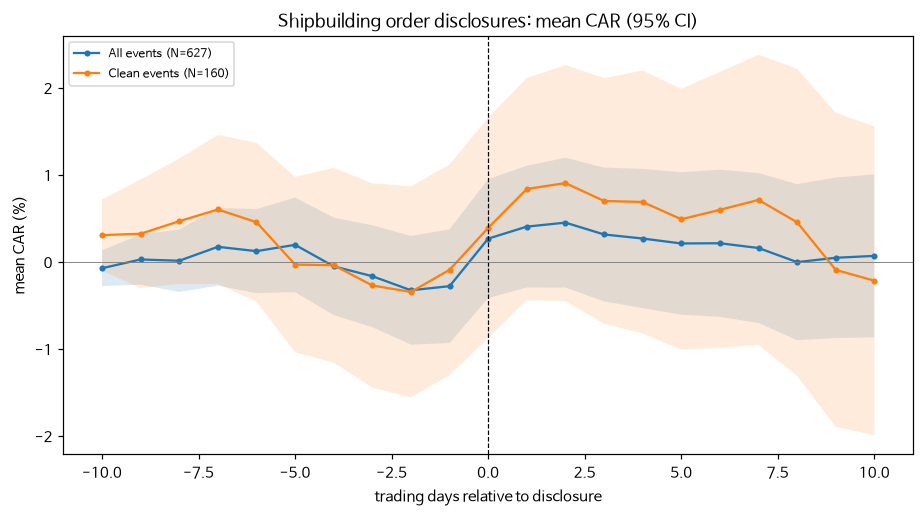

■ 종목별


pre[-10,-1](%)       ann[0,+1](%)      
                        mean count         mean count
firm                                                 
HD HHI               -1.5776    75       0.5364    75
HD KSOE(Hold)         0.0697   206       0.5667   206
HD Mipo               0.4080   108       0.6940   108
Hanwha Ocean          0.2364   106       0.6865   106
Samsung HI           -1.0793   132       0.9422   132

해석: [0,+1]이 작고 [-10,-1]이 유의 → 수주 정보가 공시 전에 이미 가격에 반영(H1·H2 지지)


In [11]:
AR_all = run_event_study(events, ret, mkt)
ev_ok  = events.loc[AR_all.index].copy()
AR_clean = AR_all.loc[ev_ok.index[ev_ok["clean"]]]

tblB1_all, tblB1_clean = car_table(AR_all), car_table(AR_clean)
print("■ 전체 이벤트"); display(tblB1_all)
print("■ Clean 이벤트 (앞뒤 10거래일 내 다른 공시 없음)"); display(tblB1_clean)
pd.concat({"all": tblB1_all, "clean": tblB1_clean}).to_csv(f"{OUT_DIR}/B1_car_table.csv", encoding="utf-8-sig")
plot_car({"All events": AR_all, "Clean events": AR_clean},
         "Shipbuilding order disclosures: mean CAR (95% CI)", f"{OUT_DIR}/fig_B1_car.png")

firm = pd.DataFrame({
    "pre[-10,-1](%)": car(AR_all, -10, -1) * 100,
    "ann[0,+1](%)":   car(AR_all, 0, 1) * 100,
    "firm": ev_ok["ticker"].map(NAME)}).groupby("firm").agg(["mean", "count"])
print("■ 종목별"); display(firm)
firm.to_csv(f"{OUT_DIR}/B1_car_by_firm.csv", encoding="utf-8-sig")
print("해석: [0,+1]이 작고 [-10,-1]이 유의 → 수주 정보가 공시 전에 이미 가격에 반영(H1·H2 지지)")

### H3 — 테마 강도에 따라 반응이 달라지는가 + 경쟁사 스필오버
- 레짐은 **공시 전날(t−1)** 기준 → 공시 자체가 상관을 올리는 역인과 방지  
- 스필오버: 공시 기업과 **다른 그룹**의 조선사 CAR 평균 (HD그룹 내 지주-자회사는 제외).  
  같은 날 같은 그룹 공시(예: 지주사+자회사 동시 공시)는 한 번만 셉니다.

■ 레짐별 자사 CAR (%)


own_pre       own_ann      
          mean count    mean count
regime                            
Low    -2.3439    89  0.1346    89
Mid     0.1697   342  0.9375   342
High   -0.1366   196  0.4921   196

■ 레짐별 경쟁사 CAR (%)


peer_pre       peer_ann      
           mean count     mean count
regime                              
Low     -0.8026    72   0.2288    72
Mid     -0.1515   304   0.2602   304
High    -2.1879   164  -0.0116   164

,High − Low (%p),Welch p
variable,,
own_ann,0.3574,0.4513
own_pre,2.2073,0.0147
peer_ann,-0.2405,0.6001
peer_pre,-1.3853,0.1686


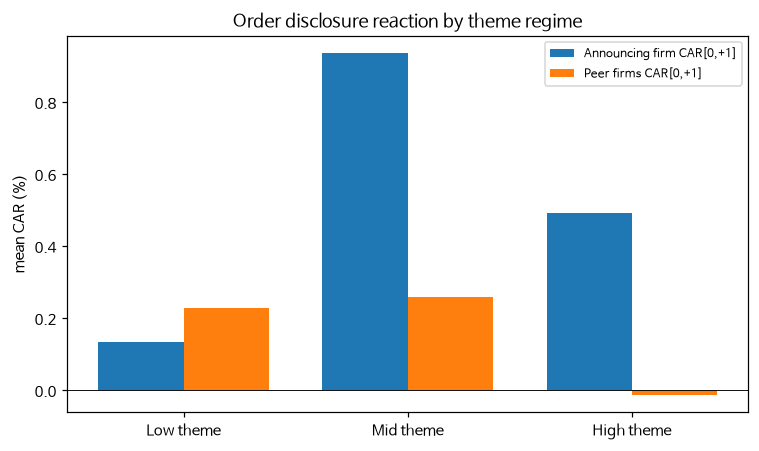

해석: High에서 자사 반응↓·경쟁사 반응↑ → 테마 구간엔 개별 수주가 '섹터 뉴스'로 소비됨(H3 지지)


In [12]:
rank_lag = theme_rank.shift(1)
ev_ok["regime"] = to_regime(rank_lag.reindex(ev_ok["tdate"])).values
ev_ok["own_pre"] = car(AR_all, -10, -1)
ev_ok["own_ann"] = car(AR_all, 0, 1)

# --- 경쟁사 스필오버 ---
src = ev_ok.assign(grp=ev_ok["ticker"].map(GROUP)).drop_duplicates(["grp", "tdate"])
peer_rows = []
for i, e in src.iterrows():
    for p in ret.columns:
        if p in CORR_EXCLUDE or GROUP.get(p) == GROUP[e["ticker"]]:
            continue
        peer_rows.append({"src": i, "ticker": p, "tdate": e["tdate"], "pos": e["pos"]})
peer_ev = pd.DataFrame(peer_rows)
AR_peer = run_event_study(peer_ev, ret, mkt)
peer_ev = peer_ev.loc[AR_peer.index]
peer = pd.DataFrame({"src": peer_ev["src"].values,
                     "peer_pre": car(AR_peer, -10, -1).values,
                     "peer_ann": car(AR_peer, 0, 1).values}).groupby("src").mean()
src = src.join(peer, how="inner")

def regime_table(df, cols):
    out = df.groupby("regime", observed=False)[cols].agg(["mean", "count"])
    for c in cols:
        out[(c, "mean")] *= 100
    return out

tblB2_own, tblB2_peer = regime_table(ev_ok, ["own_pre", "own_ann"]), regime_table(src, ["peer_pre", "peer_ann"])
print("■ 레짐별 자사 CAR (%)"); display(tblB2_own)
print("■ 레짐별 경쟁사 CAR (%)"); display(tblB2_peer)
tblB2_own.to_csv(f"{OUT_DIR}/B2_own_car_by_regime.csv", encoding="utf-8-sig")
tblB2_peer.to_csv(f"{OUT_DIR}/B2_peer_car_by_regime.csv", encoding="utf-8-sig")

def welch(df, col):
    a = df.loc[df["regime"] == "High", col].dropna(); b = df.loc[df["regime"] == "Low", col].dropna()
    if len(a) < 3 or len(b) < 3:
        return np.nan, np.nan
    t, p = stats.ttest_ind(a, b, equal_var=False)
    return (a.mean() - b.mean()) * 100, p

rows = []
for df, col in [(ev_ok, "own_ann"), (ev_ok, "own_pre"), (src, "peer_ann"), (src, "peer_pre")]:
    d, p = welch(df, col); rows.append({"variable": col, "High − Low (%p)": d, "Welch p": p})
tblB2_welch = pd.DataFrame(rows).set_index("variable")
display(tblB2_welch)
tblB2_welch.to_csv(f"{OUT_DIR}/B2_welch_high_vs_low.csv", encoding="utf-8-sig")

labels = ["Low", "Mid", "High"]
own = [ev_ok.loc[ev_ok["regime"] == g, "own_ann"].mean() * 100 for g in labels]
prr = [src.loc[src["regime"] == g, "peer_ann"].mean() * 100 for g in labels]
x = np.arange(3); w = 0.38
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(x - w/2, own, w, label="Announcing firm CAR[0,+1]")
ax.bar(x + w/2, prr, w, label="Peer firms CAR[0,+1]")
ax.set_xticks(x); ax.set_xticklabels([f"{g} theme" for g in labels]); ax.axhline(0, color="k", lw=0.6)
ax.set_ylabel("mean CAR (%)"); ax.set_title("Order disclosure reaction by theme regime"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig_B2_regime.png", bbox_inches="tight"); plt.show()
print("해석: High에서 자사 반응↓·경쟁사 반응↑ → 테마 구간엔 개별 수주가 '섹터 뉴스'로 소비됨(H3 지지)")

### (선택) 계약 규모 효과 — 매출액 대비 계약금액
공시 원문에서 '매출액 대비(%)'를 파싱합니다. 공시 양식이 조금씩 달라 일부는 실패(NaN)할 수 있고, 이벤트 수만큼 API를 호출하므로 몇 분 걸립니다.

In [13]:
RUN_SIZE = False     # True로 바꾸면 실행

def parse_sales_ratio(rcept_no):
    try:
        xml = dart.document(rcept_no)
    except Exception:
        return np.nan
    txt = re.sub(r"<[^>]+>", " ", str(xml)); txt = re.sub(r"\s+", " ", txt)
    m = re.search(r"매출액\s*대비\s*\(?\s*%?\s*\)?\s*([0-9]+(?:\.[0-9]+)?)", txt)
    return float(m.group(1)) if m else np.nan

if RUN_SIZE:
    ratios = []
    for rn in ev_ok["rcept_no"]:
        ratios.append(parse_sales_ratio(rn)); time.sleep(0.15)
    ev_ok["sales_ratio"] = ratios
    print("파싱 성공률:", ev_ok["sales_ratio"].notna().mean().round(2))
    med = ev_ok["sales_ratio"].median()
    ev_ok["size_grp"] = np.where(ev_ok["sales_ratio"] >= med, "Large", "Small")
    ev_ok.loc[ev_ok["sales_ratio"].isna(), "size_grp"] = np.nan
    display(ev_ok.groupby("size_grp")[["own_pre", "own_ann"]].agg(["mean", "count"]))

---
## 결과 저장
`events_with_car.csv`에는 이벤트별 CAR이 들어 있습니다. 사전 CAR이 큰 이벤트 몇 개를 골라 **공시 전 언론 보도가 있었는지** 직접 확인하면 H2를 사례로 보강할 수 있습니다.

In [14]:
out = ev_ok.assign(firm=ev_ok["ticker"].map(NAME))[
    ["firm", "tdate", "report_nm", "n_contracts", "clean", "regime", "own_pre", "own_ann"]]
out.to_csv(f"{OUT_DIR}/events_with_car.csv", index=False, encoding="utf-8-sig")
tblA2.to_csv(f"{OUT_DIR}/A2_regime_forward.csv", encoding="utf-8-sig")
print(f"저장 완료({OUT_DIR}/): events_with_car.csv, A2_regime_forward.csv, fig_A1_theme.png, fig_B1_car.png, fig_B2_regime.png")
print("\n사전 CAR 상위 10개 이벤트 (뉴스 확인용):")
display(out.sort_values("own_pre", ascending=False).head(10))

저장 완료(outputs/): events_with_car.csv, A2_regime_forward.csv, fig_A1_theme.png, fig_B1_car.png, fig_B2_regime.png

사전 CAR 상위 10개 이벤트 (뉴스 확인용):


,firm,tdate,report_nm,n_contracts,clean,regime,own_pre,own_ann
552,Hanwha Ocean,2024-11-18,단일판매ㆍ공급계약체결,1,False,High,0.4706,-0.0847
493,Hanwha Ocean,2020-06-08,단일판매ㆍ공급계약체결,1,True,Mid,0.3790,0.0313
657,HD HHI,2026-05-04,단일판매ㆍ공급계약체결,1,False,High,0.3011,-0.1410
543,Hanwha Ocean,2024-03-25,단일판매ㆍ공급계약체결,1,False,Mid,0.2785,-0.0450
502,Hanwha Ocean,2021-05-12,단일판매ㆍ공급계약체결,1,False,Mid,0.2747,-0.0324
632,HD HHI,2024-11-18,단일판매ㆍ공급계약체결,1,True,High,0.2428,0.0270
551,Hanwha Ocean,2024-11-11,단일판매ㆍ공급계약체결,1,False,High,0.2213,0.0578
501,Hanwha Ocean,2021-04-30,단일판매ㆍ공급계약체결,1,False,High,0.2203,0.1050
445,HD Mipo,2024-05-02,단일판매ㆍ공급계약체결,1,False,High,0.2193,-0.0354
302,Samsung HI,2023-07-17,단일판매ㆍ공급계약체결,1,True,Mid,0.2030,-0.0079


---
# Part C. 매매전략 — 테마 과열 회피 & 수주 모멘텀
Part A·B에서 찾은 현상을 실제 포지션으로 옮깁니다. **공매도 없이 롱온리**로만 구성해 개인도 실행 가능한 형태로 만들고,
모든 신호는 t일 종가까지의 정보로 만들어 **t+1일 수익률**에 적용합니다 (룩어헤드 차단).

| 전략 | 신호 | 논리 |
|---|---|---|
| S1 테마 과열 회피 | 테마 강도 백분위 ≥ 0.8이면 비중 0 | 과열 구간 이후 반전(A2) |
| S2 수주 모멘텀 | 최근 60거래일 수주 공시 건수가 과거 대비 상위면 비중 1 | 수주 증가 = 펀더멘털 개선 |
| S3 결합 | S1·S2 모두 만족할 때만 보유 | 두 신호의 교집합 |
| B&H | 항상 보유 | 벤치마크 |

비용은 매수 수수료, 매도 수수료·거래세를 회전율에 곱해 차감합니다. **세율은 최신 기준으로 확인해서 넣으세요.**

In [15]:
COST_BUY  = 0.00015              # 매수 수수료
COST_SELL = 0.00015 + 0.0015     # 매도 수수료 + 거래세 (※ 최신 세율 확인 후 수정)
IS_END    = "2020-12-31"         # 여기까지 In-sample, 이후 Out-of-sample

sector_ret = ret[corr_cols].mean(axis=1, skipna=True).fillna(0)   # 동일가중 조선 섹터
bench      = mkt.fillna(0)

def backtest(weight, asset_ret, cost_buy=COST_BUY, cost_sell=COST_SELL):
    w = weight.shift(1).fillna(0).clip(0, 1)          # t 신호 → t+1 적용
    dw = w.diff().fillna(w)
    cost = dw.clip(lower=0) * cost_buy + (-dw).clip(lower=0) * cost_sell
    gross = w * asset_ret
    return pd.DataFrame({"w": w, "gross": gross, "net": gross - cost, "cost": cost})

def metrics(r, name="", rf=0.0):
    r = r.dropna()
    if len(r) < 60:
        return {}
    cum = (1 + r).prod()
    yrs = len(r) / 252
    cagr = cum ** (1 / yrs) - 1
    vol = r.std() * np.sqrt(252)
    eq = (1 + r).cumprod()
    mdd = (eq / eq.cummax() - 1).min()
    return {"strategy": name, "CAGR(%)": cagr * 100, "Vol(%)": vol * 100,
            "Sharpe": (cagr - rf) / vol if vol > 0 else np.nan, "MDD(%)": mdd * 100,
            "Calmar": cagr / abs(mdd) if mdd < 0 else np.nan,
            "Hit(%)": (r > 0).mean() * 100, "Days": len(r)}

In [16]:
# S1 : 테마 과열이 아니면 보유
sig1 = (theme_rank < 0.8).astype(float)
sig1[theme_rank.isna()] = 1.0          # 레짐 판정 전 구간은 단순 보유

# S2 : 수주 공시 강도 (최근 60거래일 건수의 과거 대비 백분위)
cnt = pd.Series(0.0, index=ret.index)
vc = events.groupby("tdate")["n_contracts"].sum()
cnt.loc[cnt.index.intersection(vc.index)] = vc.reindex(cnt.index.intersection(vc.index)).values
flow = cnt.rolling(60).sum()
flow_rank = flow.expanding(min_periods=250).rank(pct=True)
sig2 = (flow_rank >= 0.4).astype(float)
sig2[flow_rank.isna()] = 1.0

sig3 = ((sig1 > 0) & (sig2 > 0)).astype(float)
bh   = pd.Series(1.0, index=ret.index)

STRATS = {"B&H (sector)": bh, "S1 theme-filter": sig1, "S2 order-momentum": sig2, "S3 combined": sig3}
print("평균 투자 비중:", {k: round(v.shift(1).fillna(0).mean(), 2) for k, v in STRATS.items()})

평균 투자 비중: {'B&H (sector)': np.float64(1.0), 'S1 theme-filter': np.float64(0.78), 'S2 order-momentum': np.float64(0.93), 'S3 combined': np.float64(0.71)}


,CAGR(%),Vol(%),Sharpe,MDD(%),Calmar,Hit(%),Days,turnover/yr,cost drag(%p)
strategy,,,,,,,,,
B&H (sector),8.3346,39.5861,0.2105,-81.5379,0.1022,48.4174,2875,0.0877,0.0015
S1 theme-filter,5.6481,33.9186,0.1665,-78.0660,0.0723,37.4957,2875,8.0640,0.7703
S2 order-momentum,7.3099,38.6006,0.1894,-81.7150,0.0895,45.0435,2875,0.6136,0.0523
S3 combined,4.7354,32.7631,0.1445,-78.0701,0.0607,34.1565,2875,8.4146,0.7969
KOSPI,11.5799,22.6873,0.5104,-43.8979,0.2638,54.4348,2875,NaN,NaN


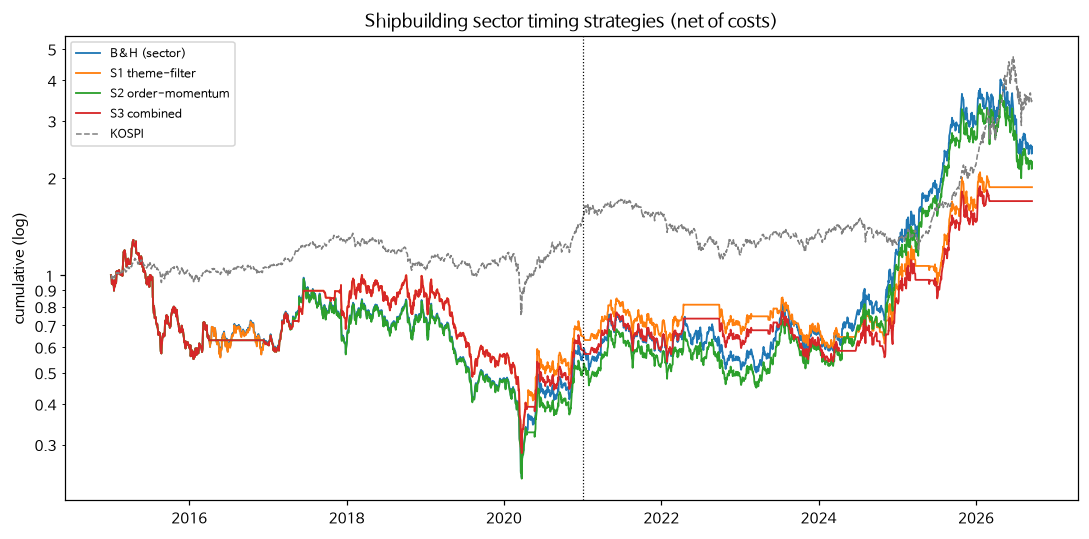

In [17]:
res, rows = {}, []
for name, sig in STRATS.items():
    bt = backtest(sig, sector_ret)
    res[name] = bt
    m = metrics(bt["net"], name)
    m["turnover/yr"] = bt["w"].diff().abs().sum() / (len(bt) / 252)
    m["cost drag(%p)"] = (metrics(bt["gross"], name)["CAGR(%)"] - m["CAGR(%)"])
    rows.append(m)
rows.append(metrics(bench, "KOSPI"))
tblC1 = pd.DataFrame(rows).set_index("strategy")
display(tblC1)
tblC1.to_csv(f"{OUT_DIR}/C1_backtest_full.csv", encoding="utf-8-sig")

fig, ax = plt.subplots(figsize=(10, 5))
for name, bt in res.items():
    ax.plot(bt.index, (1 + bt["net"]).cumprod(), lw=1.2, label=name)
ax.plot(bench.index, (1 + bench).cumprod(), lw=1, color="grey", ls="--", label="KOSPI")
ax.axvline(pd.Timestamp(IS_END), color="k", lw=0.8, ls=":")
ax.set_yscale("log"); ax.set_ylabel("cumulative (log)"); ax.legend(fontsize=8)
from matplotlib.ticker import FuncFormatter   # 로그축 10^-1 표기의 마이너스 글리프 깨짐 방지 → 일반 숫자 표기
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
ax.yaxis.set_minor_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
ax.set_title("Shipbuilding sector timing strategies (net of costs)")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/fig_C1_equity.png", bbox_inches="tight"); plt.show()

### 과최적화 점검 — 기간 분리 & 파라미터 민감도
앞 기간에서 정한 규칙이 뒤 기간에도 통하는지, 임계값을 바꿔도 결론이 유지되는지 봅니다.
여기서 결과가 무너지면 "이 전략은 표본 안에서만 작동했다"가 정직한 결론입니다.

In [18]:
rows = []
for name, bt in res.items():
    for lbl, sl in [("In-sample", slice(None, IS_END)), ("Out-of-sample", slice(IS_END, None))]:
        m = metrics(bt["net"].loc[sl], name); m["period"] = lbl
        if m: rows.append(m)
tblC2 = pd.DataFrame(rows).set_index(["period", "strategy"])
display(tblC2[["CAGR(%)", "Sharpe", "MDD(%)"]])
tblC2.to_csv(f"{OUT_DIR}/C2_is_oos.csv", encoding="utf-8-sig")

grid = []
for thr in [0.7, 0.75, 0.8, 0.85, 0.9]:
    for cost_mult in [0, 1, 2]:
        s = (theme_rank < thr).astype(float); s[theme_rank.isna()] = 1.0
        bt = backtest(s, sector_ret, COST_BUY * cost_mult, COST_SELL * cost_mult)
        m = metrics(bt["net"], f"thr={thr}")
        grid.append({"threshold": thr, "cost x": cost_mult, "CAGR(%)": m["CAGR(%)"],
                     "Sharpe": m["Sharpe"], "MDD(%)": m["MDD(%)"]})
tblC3 = pd.DataFrame(grid)
display(tblC3.pivot_table(index="threshold", columns="cost x", values=["CAGR(%)", "Sharpe"]))
tblC3.to_csv(f"{OUT_DIR}/C3_sensitivity_grid.csv", index=False, encoding="utf-8-sig")
print("해석: 임계값·비용을 바꿔도 Sharpe 순서가 유지되면 강건, 특정 조합에서만 좋으면 과최적화 의심")

,,CAGR(%),Sharpe,MDD(%)
period,strategy,,,
In-sample,B&H (sector),-9.4292,-0.2497,-81.5379
Out-of-sample,B&H (sector),30.8318,0.7446,-44.7778
In-sample,S1 theme-filter,-7.1571,-0.1961,-78.0660
Out-of-sample,S1 theme-filter,21.0543,0.6800,-30.0356
In-sample,S2 order-momentum,-11.0916,-0.3106,-81.7150
Out-of-sample,S2 order-momentum,30.8318,0.7446,-44.7778
In-sample,S3 combined,-8.7139,-0.2535,-78.0701
Out-of-sample,S3 combined,21.0543,0.6800,-30.0356


CAGR(%)                 Sharpe              
cost x          0       1       2      0      1      2
threshold                                             
0.7000     6.8178  6.1452  5.4757 0.2160 0.1946 0.1734
0.7500     4.6715  4.2097  3.7493 0.1422 0.1281 0.1141
0.8000     6.4183  5.6481  4.8822 0.1892 0.1665 0.1439
0.8500     7.4612  6.8518  6.2449 0.2100 0.1928 0.1757
0.9000    11.4561 11.0872 10.7190 0.3127 0.3027 0.2926

해석: 임계값·비용을 바꿔도 Sharpe 순서가 유지되면 강건, 특정 조합에서만 좋으면 과최적화 의심
